# Thực nghiệm người 1: Multinomial Naive Bayes

Phân loại SMS tiếng Việt: Ham=0, Spam=1. Count và TF-IDF dùng chung preprocessing/config. Tham khảo EDA từ [DU_AN_SPAM](https://github.com/Cham0703/DU_AN_SPAM); dữ liệu từ [Vietnamese SMS Dataset](https://github.com/trannguyenthaituan251209/vietnamese_sms_dataset).

## Cơ sở và thiết kế

Naive Bayes chọn lớp có log xác suất hậu nghiệm lớn nhất: log P(c) + tổng x_j log P(w_j|c). Alpha=1 làm trơn để tránh xác suất bằng 0. Count đếm từ; TF-IDF giảm trọng số từ phổ biến. Unigram tiếng Việt ở đây là token phân cách bởi khoảng trắng, chưa phải tách từ ghép.

CV 5 fold trên train, vectorizer fit riêng trong từng fold. Chọn cấu hình theo CV trước khi đọc test. Test giữ nguyên, chỉ đánh giá cuối. Thời gian đo riêng model.fit và model.predict.

In [1]:
from pathlib import Path
import sys
root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'PRODUCT_REQUIREMENTS.md').exists()), None)
if root is None:
    raise RuntimeError('Mở notebook từ trong thư mục dự án AI')
sys.path.insert(0, str(root))
import pandas as pd
from IPython.display import display, Image, Markdown
from models.naive_bayes.experiment import run_experiment
out = root / 'results' / 'naive_bayes'

In [2]:
results = run_experiment()
display(results)

,model,feature,accuracy,precision,recall,f1,training_time,prediction_time
0,NaiveBayes,Count,0.854271,0.691892,0.810127,0.746356,0.003897,0.000508
1,NaiveBayes,TFIDF,0.874372,0.816794,0.677215,0.740484,0.003692,0.000516


## EDA

Missing được đếm trước khi loader thay NaN. Số từ dùng phân cách khoảng trắng; tần suất placeholder là số tin nhắn có token, không phải tổng số lần token xuất hiện.

,split,rows,missing_message,empty_message,duplicates,ham,spam
0,train,2394,0,0,303,1754,640
1,test,597,0,0,31,439,158


,label,char_count_count,char_count_mean,char_count_std,char_count_min,char_count_25%,char_count_50%,char_count_75%,char_count_max,word_count_count,word_count_mean,word_count_std,word_count_min,word_count_25%,word_count_50%,word_count_75%,word_count_max,split
0,0,1754.0,246.441847,109.704978,1.0,156.25,243.5,320.0,881.0,1754.0,46.725770,21.868443,1.0,30.0,45.0,60.0,180.0,train
1,1,640.0,144.948438,57.694182,26.0,110.75,145.0,176.0,576.0,640.0,24.718750,14.230353,1.0,21.0,28.0,31.0,117.0,train
2,0,439.0,192.421412,90.052357,19.0,144.00,173.0,240.0,857.0,439.0,36.703872,18.014549,3.0,27.0,32.0,46.0,179.0,test
3,1,158.0,142.537975,79.527957,47.0,106.00,125.0,143.0,561.0,158.0,27.500000,17.708089,2.0,22.0,24.0,29.0,114.0,test


,label,[PHONE],[BANK_ACC],[MONEY],[NUMBER],[TIME],[DATE],split
0,0,0,0,1259,969,624,512,train
1,1,0,0,211,177,40,3,train
2,0,0,0,257,326,62,28,test
3,1,0,0,75,110,22,5,test


,split,label,word,count
0,train,0,__money__,2313
1,train,0,__number__,1564
2,train,0,trong,1063
3,train,0,ngày,924
4,train,0,__url__,915
...,...,...,...,...
75,test,1,em,28
76,test,1,phí,27
77,test,1,số,26
78,test,1,có,26


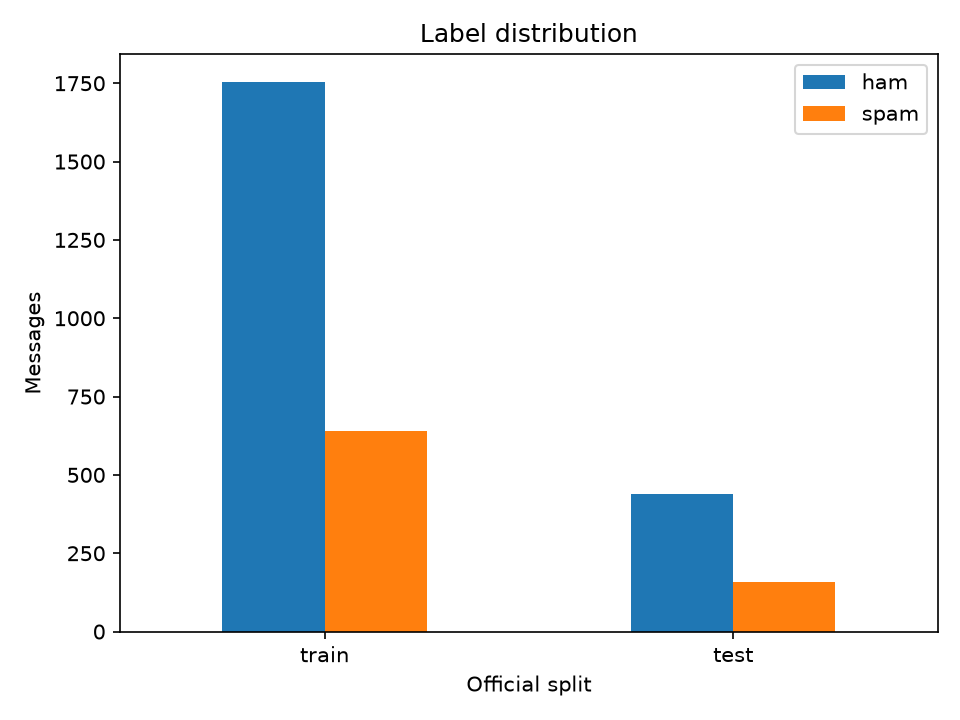

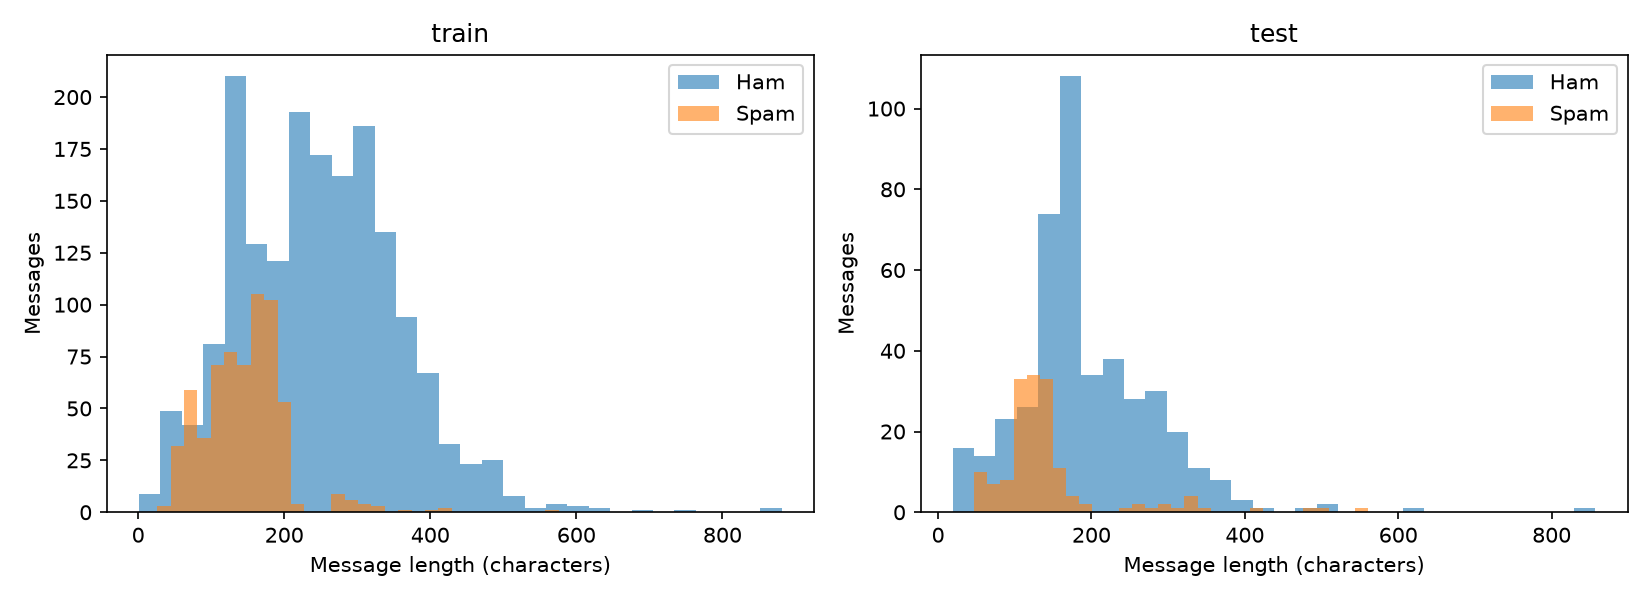

In [3]:
for name in ['eda_summary', 'eda_lengths', 'eda_placeholders', 'eda_top_words']:
    display(pd.read_csv(out / f'{name}.csv'))
for name in ['eda_labels.png', 'eda_lengths.png']:
    display(Image(filename=str(out / name)))

,feature,fold,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,Count,1,0.103811,0.048767,0.910230,0.824427,0.843750,0.833977
1,Count,2,0.099194,0.035977,0.910230,0.814815,0.859375,0.836502
2,Count,3,0.081215,0.034545,0.935282,0.859259,0.906250,0.882129
3,Count,4,0.081486,0.042149,0.881002,0.808696,0.726562,0.765432
4,Count,5,0.091938,0.036023,0.897490,0.837607,0.765625,0.800000
5,TFIDF,1,0.093200,0.042334,0.901879,0.945055,0.671875,0.785388
6,TFIDF,2,0.107253,0.039917,0.910230,0.912621,0.734375,0.813853
7,TFIDF,3,0.099915,0.042507,0.914405,0.957895,0.710938,0.816143
8,TFIDF,4,0.119330,0.045673,0.868476,0.891566,0.578125,0.701422
9,TFIDF,5,0.090441,0.042163,0.901674,0.955056,0.664062,0.783410


,mean,std
feature,,
Count,0.823608,0.043704
TFIDF,0.780043,0.046550


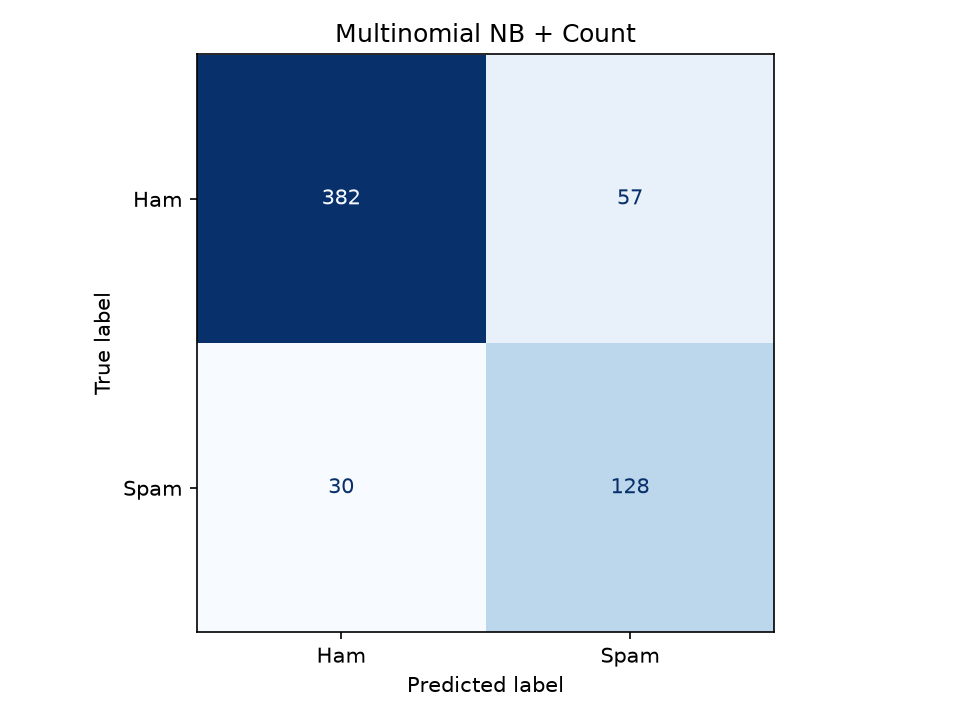

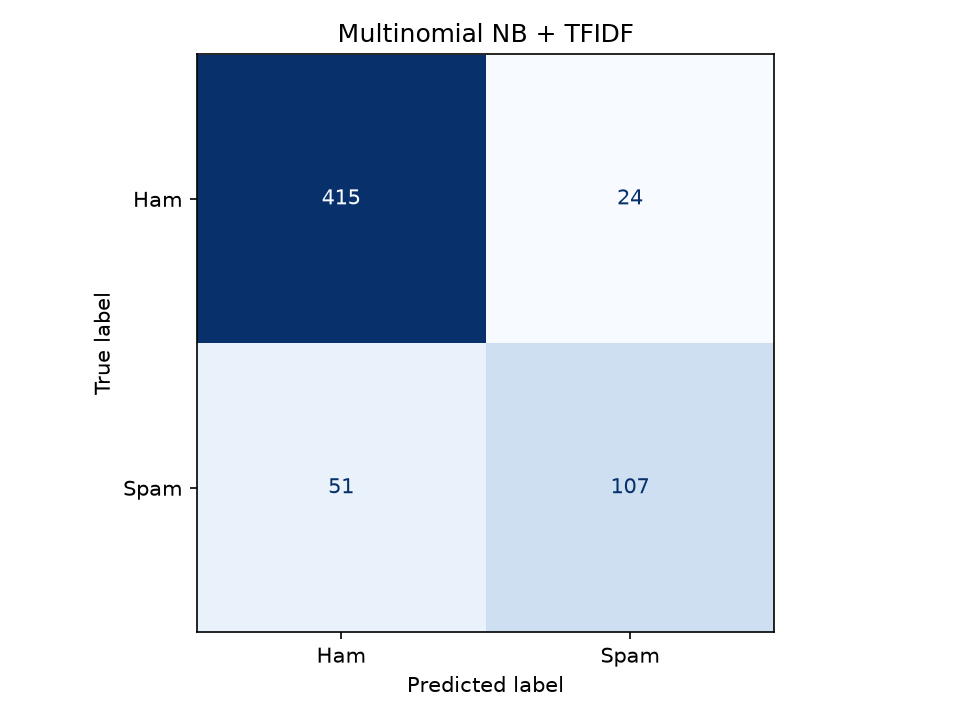

In [4]:
cv = pd.read_csv(out / 'cv_nb.csv')
display(cv)
display(cv.groupby('feature')['test_f1'].agg(['mean', 'std']))
for feature in ['count', 'tfidf']:
    display(Image(filename=str(out / f'confusion_matrix_nb_{feature}.png')))

## Phân tích lỗi

FP là tin hợp lệ bị chặn; FN là tin spam bị bỏ sót. Liệt kê tối đa 5 mẫu đầu mỗi loại cho từng cấu hình; file CSV chứa toàn bộ lỗi.

In [5]:
for feature in ['count', 'tfidf']:
    errors = pd.read_csv(out / f'errors_nb_{feature}.csv')
    for kind in ['FP', 'FN']:
        print(feature, kind, len(errors[errors.error_type == kind]))
        display(errors[errors.error_type == kind].head(5))
display(Markdown((out / 'report_nb.md').read_text(encoding='utf-8')))

count FP 57


,test_row,message,label,cleaned_message,prediction,error_type
0,0,"Để phòng ngừa bệnh tay chân miệng, người chăm ...",0,để phòng ngừa bệnh tay chân miệng người chăm s...,1,FP
1,3,(TB) Phòng Cảnh sát giao thông đường bộ - đườn...,0,tb phòng cảnh sát giao thông đường bộ đường sắ...,1,FP
2,4,(TB) Phòng Cảnh sát giao thông đường bộ - đườn...,0,tb phòng cảnh sát giao thông đường bộ đường sắ...,1,FP
3,7,(TB) Chúc mừng năm mới Quý Mão [NUMBER]! Người...,0,tb chúc mừng năm mới quý mão __number__ người ...,1,FP
4,12,Công ty điện lực thủ đức đã tiếp nhận thông ti...,0,công ty điện lực thủ đức đã tiếp nhận thông ti...,1,FP


count FN 30


,test_row,message,label,cleaned_message,prediction,error_type
57,511,[Viettel] Thuê bao của quý khách chưa chuẩn hó...,1,viettel thuê bao của quý khách chưa chuẩn hóa ...,0,FN
58,536,Hoi vien moi nap dau [MONEY] tang [MONEY] tao ...,1,hoi vien moi nap dau __money__ tang __money__ ...,0,FN
59,541,FLY88 trai nghiem moi: Dang ky nhan [MONEY]. T...,1,fly88 trai nghiem moi dang ky nhan __money__ t...,0,FN
60,543,Vao ngay WW88 vui cung WORLD CUP Nap [MONEY] n...,1,vao ngay ww88 vui cung world cup nap __money__...,0,FN
61,546,DANG KY TAI KHOAN NAP DAU 50 NHAN 50 nk99hv.com,1,dang ky tai khoan nap dau 50 nhan 50 nk99hv com,0,FN


tfidf FP 24


,test_row,message,label,cleaned_message,prediction,error_type
0,4,(TB) Phòng Cảnh sát giao thông đường bộ - đườn...,0,tb phòng cảnh sát giao thông đường bộ đường sắ...,1,FP
1,16,Trẻ em cần được học bơi và học kỹ năng an toàn...,0,trẻ em cần được học bơi và học kỹ năng an toàn...,1,FP
2,22,đơn 51/9 đường 475 a giao giùm e [TIME] đc kh ...,0,đơn 51 9 đường 475 a giao giùm e __time__ đc k...,1,FP
3,45,Telegram code: [NUMBER] \r\nYou can also tap o...,0,telegram code __number__ you can also tap on t...,1,FP
4,75,Tôi đã nhận được đơn hàng spxvn[NUMBER]a\r\nVà...,0,tôi đã nhận được đơn hàng spxvn __number__ a v...,1,FP


tfidf FN 51


,test_row,message,label,cleaned_message,prediction,error_type
24,443,VPBank thông báo: thẻ của quý khách vừa phát s...,1,vpbank thông báo thẻ của quý khách vừa phát si...,0,FN
25,454,Shopee SALE lớn: giảm tới 50% toàn bộ sản phẩm...,1,shopee sale lớn giảm tới 50 toàn bộ sản phẩm f...,0,FN
26,456,FPT Shop SALE lớn: giảm tới 50% toàn bộ sản ph...,1,fpt shop sale lớn giảm tới 50 toàn bộ sản phẩm...,0,FN
27,459,"Spa Hà ưu đãi 70% gói chăm sóc da dịp lễ, tặng...",1,spa hà ưu đãi 70 gói chăm sóc da dịp lễ tặng k...,0,FN
28,472,MB Bank thông báo: thẻ của quý khách vừa phát ...,1,mb bank thông báo thẻ của quý khách vừa phát s...,0,FN


# Kết quả thực nghiệm người 1

MultinomialNB alpha=1.0; dùng nguyên train/test chính thức. Count và TF-IDF dùng cấu hình chung, không fit vocabulary/IDF trên test.

```text
split  rows  missing_message  empty_message  duplicates  ham  spam
train  2394                0              0         303 1754   640
 test   597                0              0          31  439   158
```

```text
     model feature  accuracy  precision   recall       f1  training_time  prediction_time
NaiveBayes   Count  0.854271   0.691892 0.810127 0.746356       0.003897         0.000508
NaiveBayes   TFIDF  0.874372   0.816794 0.677215 0.740484       0.003692         0.000516
```

Cấu hình NB chọn bằng CV trên train: **Count**. Đây chưa phải mô hình tốt nhất toàn dự án; cần kết quả KNN.

Thời gian tính bằng giây, chỉ đo model.fit/model.predict, không gồm vector hóa/CV.

Số nội dung trùng train/test sau làm sạch: 31. Giữ nguyên split theo yêu cầu; cần cân nhắc khi diễn giải khả năng tổng quát hóa.

## Ví dụ lỗi

FP: Ham bị gán Spam. FN: Spam bị bỏ sót. Chọn 5 dòng đầu theo thứ tự test cho mỗi loại, mỗi cấu hình; không chọn theo xác suất.

### Count: FP (57 lỗi)

- Dòng test 0: Để phòng ngừa bệnh tay chân miệng, người chăm sóc trẻ và trẻ cần rửa tay thường xuyên bằng xà phòng; Lau sạch các bề mặt, vật dụng tiếp xúc hàng ngày như đồ chơi, bàn ghế, sàn nhà... Đưa trẻ đi khám ngay tại các cơ sở y tế gần nhất khi trẻ có các biểu hiện sốt, nổi hồng ban bóng nước ở lòng bàn tay, bàn chân, loét miệng, giật mình.
- Dòng test 3: (TB) Phòng Cảnh sát giao thông đường bộ - đường sắt Công an Thành phố Hồ Chí Minh khuyến cáo: điều khiển phương tiện sau khi đã sử dụng rượu bia là một trong những nguyên nhân hàng đầu dẫn đến các vụ tai nạn giao thông đặc biệt nghiêm trọng, để lại hậu quả thương tâm cho chính gia đình bạn và xã hội. Vì sức khỏe và an toàn của chính bạn: “Đã uống rượu bia - không lái xe”.
- Dòng test 4: (TB) Phòng Cảnh sát giao thông đường bộ - đường sắt Công an Thành phố Hồ Chí Minh khuyến cáo: Cảnh sát giao thông không gọi điện thoại để yêu cầu chuyển tiền nộp phạt vi phạm hành chính qua các link hoặc tài khoản do các đối tượng lừa đảo cung cấp. Việc nộp phạt vi phạm hành chính được thực hiện trực tiếp tại trụ sở lực lượng Cảnh sát giao thông hoặc thông qua Cổng dịch vụ công quốc gia tại địa chỉ https://dichvucong.gov.vn hoặc Cổng dịch vụ công Bộ Công an tại địa chỉ https://dichvucong.bocongan.gov.vn
- Dòng test 7: (TB) Chúc mừng năm mới Quý Mão [NUMBER]! Người dân chủ động sắp xếp thời gian trở lại nơi làm việc và sinh sống tại các thành phố lớn, tránh tình trạng ùn tắc giao thông vào cuối dịp nghỉ lễ, tuyệt đối không điều khiển phương tiện khi đã sử dụng rượu, bia và các chất kích thích khác.
- Dòng test 12: Công ty điện lực thủ đức đã tiếp nhận thông tin của quý khách ! ĐL đã cử a Hoàng khảo sát với số ĐT :[NUMBER] khảo sát ngày [DATE]

### Count: FN (30 lỗi)

- Dòng test 511: [Viettel] Thuê bao của quý khách chưa chuẩn hóa thông tin theo quy định, sẽ bị khóa 1 chiều sau [TIME]. Vui lòng gọi [NUMBER] để cập nhật.
- Dòng test 536: Hoi vien moi nap dau [MONEY] tang [MONEY] tao tai khoan moi nhan uu dai lixi moi https://www.ee8qbet.com/?ch=0b8857e136
- Dòng test 541: FLY88 trai nghiem moi: Dang ky nhan [MONEY]. Tai app nhan [MONEY]. X2 nap dau trai nghiem. Diem danh moi ngay nhan [MONEY]. Dang ky: https://fly88.health
- Dòng test 543: Vao ngay WW88 vui cung WORLD CUP Nap [MONEY] nhan [MONEY] dang cap the thao, nohu, casino tai https://ww98dt3.cc/Register? f=[NUMBER]
- Dòng test 546: DANG KY TAI KHOAN NAP DAU 50 NHAN 50 nk99hv.com

### TFIDF: FP (24 lỗi)

- Dòng test 4: (TB) Phòng Cảnh sát giao thông đường bộ - đường sắt Công an Thành phố Hồ Chí Minh khuyến cáo: Cảnh sát giao thông không gọi điện thoại để yêu cầu chuyển tiền nộp phạt vi phạm hành chính qua các link hoặc tài khoản do các đối tượng lừa đảo cung cấp. Việc nộp phạt vi phạm hành chính được thực hiện trực tiếp tại trụ sở lực lượng Cảnh sát giao thông hoặc thông qua Cổng dịch vụ công quốc gia tại địa chỉ https://dichvucong.gov.vn hoặc Cổng dịch vụ công Bộ Công an tại địa chỉ https://dichvucong.bocongan.gov.vn
- Dòng test 16: Trẻ em cần được học bơi và học kỹ năng an toàn để phòng, chống đuối nước.
- Dòng test 22: đơn 51/9 đường 475 a giao giùm e [TIME] đc kh a  Có đon od em bỏ vô nhà có j lây giúp em nha a tài  dạ oke e cảm ơn a
- Dòng test 45: Telegram code: [NUMBER]   You can also tap on this link to log in:   https://t.me/login/[NUMBER]
- Dòng test 75: Tôi đã nhận được đơn hàng spxvn[NUMBER]a  Vào lúc 13h10 ngày 6 thang 10 . Đồng ý gở khieu nai

### TFIDF: FN (51 lỗi)

- Dòng test 443: VPBank thông báo: thẻ của quý khách vừa phát sinh giao dịch [MONEY] lúc [TIME]. Nếu không phải quý khách, gọi ngay [NUMBER] để khóa thẻ.
- Dòng test 454: Shopee SALE lớn: giảm tới 50% toàn bộ sản phẩm, freeship toàn quốc. Soạn DK gửi 8x18 để nhận mã giảm giá.
- Dòng test 456: FPT Shop SALE lớn: giảm tới 50% toàn bộ sản phẩm, freeship toàn quốc. Soạn DK gửi 8x28 để nhận mã giảm giá.
- Dòng test 459: Spa Hà ưu đãi 70% gói chăm sóc da dịp lễ, tặng kèm 2 buổi trị liệu. Gọi [NUMBER] đặt lịch ngay hôm nay.
- Dòng test 472: MB Bank thông báo: thẻ của quý khách vừa phát sinh giao dịch [MONEY] lúc [TIME]. Nếu không phải quý khách, gọi ngay [NUMBER] để khóa thẻ.


In [6]:
analysis = root / 'docs' / 'member1_analysis.md'
if analysis.exists():
    display(Markdown(analysis.read_text(encoding='utf-8-sig')))

# Phân tích kết quả — Người 1

## Kết quả thực nghiệm

Dữ liệu chính thức gồm 2.394 mẫu train (1.754 Ham, 640 Spam), 597 mẫu test
(439 Ham, 158 Spam). Không có tin nhắn thiếu/rỗng. Có 303 dòng trùng
message+label trong train và 31 trong test; 31 nội dung sau làm sạch xuất hiện
ở cả train và test. Giữ nguyên split theo yêu cầu. CV chia theo dòng nên mẫu
trùng có thể nằm ở hai fold khác nhau; F1 CV có thể lạc quan.

| Cấu hình | Accuracy | Precision Spam | Recall Spam | F1 Spam | F1 CV train |
|---|---:|---:|---:|---:|---:|
| NB + Count | 85,43% | 69,19% | 81,01% | 74,64% | 82,36% |
| NB + TF-IDF | 87,44% | 81,68% | 67,72% | 74,05% | 78,00% |

Count được chọn từ CV train trước khi đọc test. Trên test, Count phát hiện
128/158 Spam nhưng chặn nhầm 57 Ham; TF-IDF phát hiện 107/158 Spam và chặn
nhầm 24 Ham. Count có Recall cao hơn, TF-IDF có Precision/Accuracy cao hơn.
F1 test hai cấu hình chỉ chênh khoảng 0,59 điểm phần trăm, chưa có kiểm định
để khẳng định khác biệt có ý nghĩa thống kê. Không thể kết luận hơn KNN
khi chưa có kết quả người 2.

## Phân tích 5 FP và 5 FN cho mỗi cấu hình

Nội dung nguyên mẫu và nhãn xem `results/naive_bayes/report_nb.md`; số dòng
bên dưới là chỉ số bắt đầu từ 0 của test.csv, không tính dòng tiêu đề.
Các diễn giải là giả thuyết từ việc đọc mẫu, không phải kết luận nhân quả
hay phép giải thích trọng số của mô hình. Nhãn được giữ theo dataset.

| Cấu hình/lỗi | Dòng | Nhận xét |
|---|---:|---|
| Count FP | 0 | Khuyến cáo y tế dài bị chặn; từ vựng ngoài chủ đề giao dịch thường gặp có thể gây nhầm. |
| Count FP | 3 | Thông báo an toàn giao thông chính thức bị nhầm; unigram không xác định được chủ thể gửi. |
| Count FP | 4 | Cảnh báo chống lừa đảo chứa “chuyển tiền”, “tài khoản”, link; mô hình khó hiểu phủ định “không”. |
| Count FP | 7 | Chúc mừng năm mới kèm khuyến cáo giao thông có cụm từ cũng gặp trong quảng cáo. |
| Count FP | 12 | Điện lực xác nhận khảo sát có số liên hệ, ngày và lời xưng hô dịch vụ; dễ lẫn tin mạo danh. |
| Count FN | 511 | Tin giả danh Viettel giống thông báo chuẩn hóa thuê bao hợp lệ, không có thông tin người gửi để phân biệt. |
| Count FN | 536 | Quảng bá cá cược không dấu, nhiều token tiền và URL; mất dấu làm khác từ vựng tiếng Việt có dấu. |
| Count FN | 541 | Quảng bá FLY88 dùng từ viết tắt, không dấu và ưu đãi; các từ có thể không đủ phân biệt. |
| Count FN | 543 | Quảng bá casino/World Cup chứa từ thương hiệu và token số; biến thể miền/từ vựng gây khó. |
| Count FN | 546 | Tin ngắn không dấu, miền nk99hv.com không có scheme nên không đổi thành __url__ bởi pipeline chung. |
| TFIDF FP | 4 | Cảnh báo chống lừa đảo bị hiểu giống nội dung lừa đảo do chia sẻ từ khóa. |
| TFIDF FP | 16 | Tin phòng chống đuối nước ngắn, ít ngữ cảnh và từ vựng chủ đề hiếm. |
| TFIDF FP | 22 | Hội thoại giao hàng viết tắt, thiếu dấu và dấu câu; token rời khó đại diện ngữ nghĩa. |
| TFIDF FP | 45 | Mã đăng nhập Telegram hợp lệ có link và số, cũng là dạng tín hiệu hay gặp trong tin giả danh. |
| TFIDF FP | 75 | Xác nhận đơn và gỡ khiếu nại có mã đơn, số giờ, lỗi chính tả; khó phân biệt bằng unigram. |
| TFIDF FN | 443 | Cảnh báo giao dịch giả danh VPBank rất giống thông báo ngân hàng thực. |
| TFIDF FN | 454 | Quảng cáo Shopee có từ thương hiệu, giảm giá và hướng dẫn đăng ký quen thuộc. |
| TFIDF FN | 456 | Quảng cáo FPT Shop cùng dạng mẫu; tên doanh nghiệp không chứng minh tính hợp lệ. |
| TFIDF FN | 459 | Quảng cáo spa đặt lịch gần với tin dịch vụ hợp lệ; ranh giới spam phụ thuộc cả ngữ cảnh đồng ý nhận. |
| TFIDF FN | 472 | Cảnh báo giả danh MB Bank có mẫu tương tự VPBank; nội dung đơn lẻ thiếu tín hiệu nguồn gửi. |

## Hạn chế và hướng phát triển

Naive Bayes giả định các đặc trưng độc lập có điều kiện, chưa hiểu phủ định
hoặc ngữ cảnh. Token ẩn danh bảo vệ thông tin cá nhân nhưng cũng làm tin
thật/giả giống nhau. Count/TF-IDF dùng unigram theo khoảng trắng, chưa tách
các từ ghép tiếng Việt. Dữ liệu mất cân bằng nên không chỉ nhìn Accuracy.

Các hướng có thể đánh giá ở vòng nghiên cứu riêng: CV theo nhóm nội dung
trùng, n-gram, chuẩn hóa miền không scheme, đánh giá tin không dấu và ngữ
cảnh người gửi. Mọi lựa chọn phải thực hiện trên train/validation và thống
nhất với người 2 trước khi sửa common/config. Không chỉnh pipeline dựa trên
các lỗi test này rồi coi kết quả chạy lại là đánh giá độc lập.

## Bàn giao

Đã có hai cấu hình, CV, metrics, thời gian, hai confusion matrix, EDA, bảng
lỗi, notebook và model/vectorizer riêng. Chưa tích hợp KNN, chưa chọn best
model toàn dự án, chưa push/merge GitHub. Tham khảo và lệnh tái lập nằm trong
`models/naive_bayes/README.md`.


## Hạn chế và bàn giao

Kết quả trên split này không đảm bảo chất lượng với SMS ngoài thực tế. Các mẫu gần trùng và token ẩn danh có thể ảnh hưởng kết quả. Phân tích test chỉ để báo cáo; không dùng để chỉnh tham số rồi đánh giá lại như test độc lập. Chưa kết luận NB hay KNN tốt hơn trước khi người 2 bàn giao.

Chạy lại: `python scripts/run_nb.py`. Xem `models/naive_bayes/README.md`.